In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
File: convert_tng_to_spam.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Apr-11

Description: This script is designed to take the dynamic kinematic data from the IllustrisTNG subhalo data, 
    and convert it into a format that can be used by the SPAM simulator. 

References:  Sections of this code were written with the assistance of ChatGPT made by OpenAI.

"""
# ================================ IMPORTS ================================ #

import argparse
import math, os, sys, gzip
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpi4py import MPI
from scipy.interpolate import CubicSpline
from scipy.interpolate import CubicHermiteSpline

# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# Import project modules
import IllustrisTNG.tng_functions as tf
import Optimization_Methods.optimization_manager as om
import Simulator.new_simulator as sim

buildEnv = True

# Set NumPy print options to reduce the precision to 3 decimal places
np.set_printoptions(precision=2)

print("Import Done")

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-iwsokmh1 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Import Done


In [2]:
# ================================ INPUT ARGUMENTS ================================ #

# Define argument parser function 
def initParser():
    # Define
    parser = argparse.ArgumentParser()

    # Generic Arguments
    parser.add_argument('-i', '--input', type=str, help='Generic Input for misc functions')
    parser.add_argument('-o', '--output', type=str, help='Generic Output for misc functions')

    parser.add_argument('-i2', '--input_2', type=str, help='Generic Input for misc functions')
    parser.add_argument('-i3', '--input_3', type=str, help='Generic Input for misc functions')
    parser.add_argument('-i4', '--input_4', type=str, help='Generic Input for misc functions')

    # Specific Arguments
    parser.add_argument('-id', '--target_id', type=int, help='Target ID')
    parser.add_argument('-ow', '--overwrite', type=bool, default = False, help='Overwrite existing files')
    parser.add_argument('-f', '--function', type=str,  help='Function to run')

    return parser

parser = initParser()
script_args = parser.parse_args()
print( "Args Defined" )

Args Defined


# CORE FUNCTIONS
The following are the core functions needed to convert from TNG to SPAM.

In [3]:
# ================================ CONSTANTS ================================ #

# Constants from Java code
G_NEWTON = 6.67430e-11         # Gravitational constant in m^3 kg^-1 s^-2
KG_PER_SOLAR_MASS = 1.98892e30   # Solar mass in kg
METERS_PER_PC = 3.08567758128e16   # Meters per parsec
SECONDS_PER_YEAR = 3.15576e7    # Seconds per year

# THESE ARE PULLED FROM JAVA CODE of SPAM
# Derived units for calculations
MU_kg = 1.0e11 * KG_PER_SOLAR_MASS  # 1e11 solar masses in kg
DU_m = 15.0 * 1000 * METERS_PER_PC  # 15 kpc in meters
TU_s = math.sqrt(DU_m * DU_m * DU_m / (G_NEWTON * MU_kg))  # Time unit in seconds (Based on Kepler's third law...?)

# SPAM standard units
spam_units = {

    # Mass unit - ( 10^11 solar masses )
    "mass_unit_solar_masses": 1e11,  # Mass unit in solar masses
    "mass_unit_kg": 1e11 * KG_PER_SOLAR_MASS,  # Mass unit in kg

    # Distance unit - ( 15 kpc )
    "distance_unit_kpc": 15.0,  # Distance unit in kiloparsecs
    "distance_units_pc": 15.0 * 1000,  # Distance unit in parsecs
    "distance_unit_m": 15.0 * 1000 * METERS_PER_PC ,  # Distance unit in meters

    # Time unit - ( roughly 85 Myr )
    "time_unit_s": None,  # To be calculated below

    # Velocity unit - ( roughly 170 km/s )
    "velocity_unit_m_per_s": None,  # To be calculated below
    "velocity_unit_km_per_s": None,  # To be calculated below

    # Acceleration unit
    "acceleration_unit_m_per_s2": None,  # To be calculated below

}

# Calculate time unit using Kepler's third law
spam_units["time_unit_s"] = math.sqrt(
    spam_units["distance_unit_m"] ** 3 / (G_NEWTON * spam_units["mass_unit_kg"])
)

# Calculate velocity unit (distance unit per time unit)
spam_units["velocity_unit_m_per_s"] = spam_units["distance_unit_m"] / spam_units["time_unit_s"]
spam_units["velocity_unit_km_per_s"] = spam_units["velocity_unit_m_per_s"] / 1000 # 1000 meters per kilometer

# Calculate acceleration unit (velocity unit per time unit)
spam_units["acceleration_unit_m_per_s2"] = spam_units["velocity_unit_m_per_s"] / spam_units["time_unit_s"]

# Dictionary of units for specific fields in the IllustrisTNG data
tng_units = {
    # Mass unit: 1e10 solar masses in grams
    "mass_unit_solar_masses": 1e10,
    "mass_unit_kg": 1e10 * KG_PER_SOLAR_MASS,  # Convert kg to grams

    # Distance unit: 1 kpc in centimeters (comoving kiloparsecs per h)
    "distance_unit_kpc": 1.0,  # 1 kpc
    "distance_unit_pc" : 1e3, # 1 kpc in pc
    "distance_unit_m": 1e3 * METERS_PER_PC, # 1 kpc in meters

    # Velocity unit: 1 km/s in cm/s
    "velocity_unit_km_per_s": 1.0,

    # Time unit: 1 Gyr in seconds
    "time_unit_Gyr": 1.0,
    "time_unit_s": 1e9 * SECONDS_PER_YEAR,  # Convert Gyr to seconds
}


# Print comparing JAVA to Fortran units
if buildEnv:
    print("Mass Comparison: ")
    print("\t - Fortran (kg):", spam_units['mass_unit_kg'])
    print("\t - JAVA (kg):", MU_kg ) 

    print("Distance Comparison: ")
    print("\t - Fortran (m):", spam_units['distance_unit_m'])
    print("\t - JAVA (m):", DU_m )

    print("Time Comparison: ")
    print("\t - Fortran (s): %e" % spam_units['time_unit_s'])
    print("\t - JAVA (s): %e" % TU_s )

    print("\nValues are the same but in different units. \n")


#   Standardized parameter array for SPAM model:
'''
    [0]: X-coordinate of the secondary galaxy's position
    [1]: Y-coordinate of the secondary galaxy's position
    [2]: Z-coordinate of the secondary galaxy's position
    [3]: X-component of the secondary galaxy's velocity
    [4]: Y-component of the secondary galaxy's velocity
    [5]: Z-component of the secondary galaxy's velocity
    [6]: Mass of the primary galaxy
    [7]: Mass of the secondary galaxy
    [8]: Outer radius of the primary galaxy
    [9]: Outer radius of the secondary galaxy
    [10]: Azimuthal angle for the primary galaxy
    [11]: Azimuthal angle for the secondary galaxy
    [12]: Inclination angle for the primary galaxy
    [13]: Inclination angle for the secondary galaxy
    [14]: Softening length for the primary galaxy
    [15]: Softening length for the secondary galaxy
    [16-19]: Particle distribution of the primary galaxy. (Unused)
    [19-21]: Particle distribution of the secondary galaxy. (Unused)
'''


Mass Comparison: 
	 - Fortran (kg): 1.98892e+41
	 - JAVA (kg): 1.98892e+41
Distance Comparison: 
	 - Fortran (m): 4.62851637192e+20
	 - JAVA (m): 4.62851637192e+20
Time Comparison: 
	 - Fortran (s): 2.733073e+15
	 - JAVA (s): 2.733073e+15

Values are the same but in different units. 



"\n    [0]: X-coordinate of the secondary galaxy's position\n    [1]: Y-coordinate of the secondary galaxy's position\n    [2]: Z-coordinate of the secondary galaxy's position\n    [3]: X-component of the secondary galaxy's velocity\n    [4]: Y-component of the secondary galaxy's velocity\n    [5]: Z-component of the secondary galaxy's velocity\n    [6]: Mass of the primary galaxy\n    [7]: Mass of the secondary galaxy\n    [8]: Outer radius of the primary galaxy\n    [9]: Outer radius of the secondary galaxy\n    [10]: Azimuthal angle for the primary galaxy\n    [11]: Azimuthal angle for the secondary galaxy\n    [12]: Inclination angle for the primary galaxy\n    [13]: Inclination angle for the secondary galaxy\n    [14]: Softening length for the primary galaxy\n    [15]: Softening length for the secondary galaxy\n    [16-19]: Particle distribution of the primary galaxy. (Unused)\n    [19-21]: Particle distribution of the secondary galaxy. (Unused)\n"

In [4]:
def convert_numpy_arrays( df ):
    """
    Convert strings of arrays into numpy arrays in a pandas DataFrame.
    """

    # Function to convert a string representation of a numpy array back to a numpy array
    def convert_to_numpy_array(array_str):
        # Remove the brackets and split the string by whitespace
        array_str = array_str.strip('[]')
        # Convert to a numpy array of integers (or float if needed)
        return np.array(array_str.split(), dtype=float)
    
    # Iterate over each column and convert strings to numpy arrays if necessary
    for column in df.columns:
        # Check if the column contains array-like strings
        if df[column].dtype == object and df[column].str.startswith('[').all():
            df[column] = df[column].apply(convert_to_numpy_array)

    return df

if buildEnv and True:
    
    # Specify the file path to illustrisTNG Target info
    file_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl'

    # Read the CSV file into a Pandas DataFrame
    tng_targets = pd.read_pickle(file_path, )
    print(f"All Targets: {len(tng_targets)}")

    # Print special note of pre-fixes in file
    print("#####   SPECIAL NOTE   #####")
    print("1st character 'p' vs 's' indicates 'primary' vs 'secondary' galaxy.")
    print("If 2nd character is absent, data is from illustrisTNG Subhalo Catalog Data.")
    print("If 2nd character is present, data is dynamically calculated after doing historical particle re-attribution.")
    print("2nd characters 'a' and 's' stand for 'all particles' and 'star particles' respectively.")
    print("")
    
    print( tng_targets.columns )
    # for i, k in enumerate(tng_targets.columns):
    #     print(i, k)

    

All Targets: 1268
#####   SPECIAL NOTE   #####
1st character 'p' vs 's' indicates 'primary' vs 'secondary' galaxy.
If 2nd character is absent, data is from illustrisTNG Subhalo Catalog Data.
If 2nd character is present, data is dynamically calculated after doing historical particle re-attribution.
2nd characters 'a' and 's' stand for 'all particles' and 'star particles' respectively.

Index(['moi_2', 'snap', 'merger_snap', 'p_moi_1', 's_moi_1', 'xy_projection',
       'p_face_projection', 's_face_projection', 'p_SubhaloID', 's_SubhaloID',
       ...
       'sa_SubhaloPos_orbital_frame', 'sa_SubhaloCM_orbital_frame',
       'sa_SubhaloVel_orbital_frame', 'sa_SubhaloSpin_orbital_frame',
       'ss_SubhaloPos_orbital_frame', 'ss_SubhaloCM_orbital_frame',
       'ss_SubhaloVel_orbital_frame', 'ss_SubhaloSpin_orbital_frame',
       'img_name_review_1', 'moi_4_rating'],
      dtype='object', length=111)


In [5]:
# Let's focus on a single target for development purposes
if buildEnv:

    # Convert entire column of moi_1, moi_2, p_SubhaloIDRaw, s_SubhaloIDRaw to int64
    # tng_targets['moi_1'] = tng_targets['moi_1'].astype('int64')
    tng_targets['moi_2'] = tng_targets['moi_2'].astype('int64')
    tng_targets['p_SubhaloIDRaw'] = tng_targets['p_SubhaloIDRaw'].astype('int64')
    tng_targets['s_SubhaloIDRaw'] = tng_targets['s_SubhaloIDRaw'].astype('int64')

    # Unique ID for primary galaxy
    pid = 62000000190717

    # Get row with this p_SubhaloIDRaw
    t_row = tng_targets.loc[ tng_targets['p_SubhaloIDRaw'] == pid ].iloc[0]

    # Get moi_2 id and grab all rows with this value
    m2_id = t_row['moi_2']
    print( f'MOI_2: {m2_id}' )
    t_df = tng_targets.loc[ tng_targets['moi_2'] == m2_id ]
    print(f'Target DF: {len(t_df)}\n')

    print(f'Target Row:\n{t_row}')


MOI_2: 67000000184181
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloCM_orbital_frame      [16.59689896769487, 0.6179258303454844, 0.0204...
ss_SubhaloVel_orbital_frame     [8.724396910270222, -58.22408825900726, -12.10...
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_review_1                                       Target_62000000190717.png
moi_4_rating                                                                    5
Name: 1010, Length: 111, dtype: object


In [6]:
# ================================ FUNCTIONS ================================ #
def calculate_orientation_angles( spin ):
    """
    Calculate the azimuthal and inclination angles from the spin components.

    Parameters:
    spin (float array): [ x, y, z ] components of the spin.

    Returns:
    tuple: (phi, theta) where phi is the azimuthal angle and theta is the inclination angle,
            both in radians.
    """
    x, y, z = spin
    # Calculate the magnitude of the vector
    r = np.sqrt(x**2 + y**2 + z**2)

    # Calculate the azimuthal angle in radians
    phi = np.arctan2(y, x)  # This returns the angle in the range [-pi, pi]

    # Calculate the inclination angle in radians
    if r == 0:
        theta = 0  # Undefined direction for a zero vector, set arbitrarily to 0
    else:
        theta = np.arccos(z / r)

    return np.degrees(phi), np.degrees(theta)



In [7]:
def standardize_tng_parameters_v1( subhalo_kinematics, radius_scale=2.5 ):
    """
    Construct the standardized parameter array for kinematic data from the IllustrisTNG subhalo catalog.
    Uses a mix of the catalog data, and calculated dynamics of all particles or star particles. 

    Args:
        subhalo_kinematics (pd.Series): The dynamic kinematic data calculated elsewhere.

    Returns:
        param_array (np.array): A standardized parameter array based on the SPAM simulator.
    """
    # Initialize the parameter array
    tng_ar = np.zeros(22)

    # position and velocity. 
    # Primary is always at origin, secondary is in reference to primary's location
    for i in range(3):
        # tng_ar[i] = subhalo_kinematics['ss_SubhaloCM'][i] - subhalo_kinematics['ps_SubhaloCM'][i]  # position
        tng_ar[i] = subhalo_kinematics['s_SubhaloPos_orbital_frame'][i] - subhalo_kinematics['p_SubhaloPos_orbital_frame'][i]  # position
        tng_ar[i+3] = subhalo_kinematics['ss_SubhaloVel_orbital_frame'][i] - subhalo_kinematics['ps_SubhaloVel_orbital_frame'][i]  # velocity

    # masses, using total mass
    tng_ar[6] = subhalo_kinematics['pa_SubhaloMass']
    tng_ar[7] = subhalo_kinematics['sa_SubhaloMass']
    
    # Radii, using stars to disk radii
    # Use scale of half mass radius
    tng_ar[8] = radius_scale * subhalo_kinematics['ps_SubhaloHalfmassRad']
    tng_ar[9] = radius_scale * subhalo_kinematics['ss_SubhaloHalfmassRad']

    # orientation angles, using stars to orient disk
    tng_ar[10], tng_ar[12] = calculate_orientation_angles( subhalo_kinematics['ps_SubhaloSpin_orbital_frame'] )
    tng_ar[11], tng_ar[13] = calculate_orientation_angles( subhalo_kinematics['ss_SubhaloSpin_orbital_frame'] )

    # Just use a scale of previously radius value
    s = 0.1
    tng_ar[14] = s * tng_ar[8]
    tng_ar[15] = s * tng_ar[9]

    # Use 0 for bulge, disk, and halo.  
    # # SPAM might be able to estimate these values....? 
    tng_ar[16:22] = np.zeros(6)    

    return tng_ar

if buildEnv:
    # test_target = tng_targets.iloc[0]
    #print( test_target )
    test_tng_ar = standardize_tng_parameters_v1( t_row )
    print( test_tng_ar )


[ 3.88e+01 -2.37e+00  3.85e-07  1.52e+01 -1.02e+02 -2.11e+01  1.20e+02
  1.10e+01  1.28e+01  1.35e+01  7.89e+01  1.39e+02  1.60e+02  1.71e+02
  1.28e+00  1.35e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00]


In [8]:
def convert_distance_tng_to_spam(tng_dist_ckpch, h=0.7):
    """
    Convert distances from TNG units (ckpc/h) to SPAM distance units.

    Parameters:
    - tng_dist_ckpch: Distance in comoving kiloparsecs per h (ckpc/h).
    - h: Hubble parameter.

    Returns:
    - spam_dist: Distance in SPAM units.
    """

    # Convert ckpc/h to ckpc (comoving kpc)
    dist_kpc = tng_dist_ckpch * h
    # Since we're working with "small scale" structures, use comoving distances as physical distances.

    # Convert ckpc to SPAM distance units (1 SPAM unit = 15 kpc)
    spam_dist = dist_kpc / spam_units["distance_unit_kpc"]
    return spam_dist


def convert_velocity_tng_to_spam(tng_vel_kms):
    """
    Convert velocities from TNG units (km/s) to SPAM velocity units.

    Parameters:
    - tng_vel_kms: Velocity in km/s.

    Returns:
    - spam_vel: Velocity in SPAM units.
    """
    # Convert km/s to SPAM velocity units
    spam_vel = tng_vel_kms / spam_units["velocity_unit_km_per_s"]
    return spam_vel


def convert_mass_tng_to_spam(tng_mass_1e10Msunh, h=0.7):
    """
    Convert masses from TNG units (1e10 M⊙/h) to SPAM mass units.

    Parameters:
    - tng_mass_1e10Msunh: Mass in units of 1e10 solar masses per h.
    - h: Hubble parameter.

    Returns:
    - spam_mass: Mass in SPAM units.
    """

    # Convert from 1e10 M⊙/h to M⊙
    mass_Msun = tng_mass_1e10Msunh * 1e10 * h

    # Convert M⊙ to SPAM mass units (1 SPAM unit = 1e11 M⊙)
    spam_mass = mass_Msun / spam_units["mass_unit_solar_masses"]
    return spam_mass


def convert_time_tng_to_spam(tng_time_Gyr):
    """
    Convert time from TNG units (Gyr) to SPAM time units.

    Parameters:
    - tng_time_Gyr: Time in Gigayears (Gyr).

    Returns:
    - spam_time: Time in SPAM units.
    """
    # Convert Gyr to seconds
    time_s = tng_time_Gyr * tng_units['time_unit_s']
    # Convert seconds to SPAM time units
    spam_time = time_s / spam_units["time_unit_s"]
    return spam_time


def convert_units_tng_to_spam(tng_ar, h=0.7):
    """
    Convert IllustrisTNG data to SPAM units.

    Parameters:
    - tng_ar: numpy array, array of targets in IllustrisTNG units.
        Expected indices:
        [0-2]: Positions (ckpc/h)
        [3-5]: Velocities (km/s)
        [6-7]: Masses (1e10 M⊙/h)
        [8-9]: Radii (ckpc/h)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (ckpc/h)
    - h: float, the Hubble parameter used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - spam_data: numpy array, target converted to SPAM units.
    """
    # Initialize spam data array
    spam_data = np.zeros(22)

    # Convert Positions (indices 0-2)
    spam_data[0:3] = convert_distance_tng_to_spam(tng_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    spam_data[3:6] = convert_velocity_tng_to_spam(tng_ar[3:6])

    # Convert Masses (indices 6-7)
    spam_data[6:8] = convert_mass_tng_to_spam(tng_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    spam_data[8:10] = convert_distance_tng_to_spam(tng_ar[8:10], h)
    spam_data[14:16] = convert_distance_tng_to_spam(tng_ar[14:16], h)

    # Use same orientation angles (indices 10-13)
    spam_data[10:14] = tng_ar[10:14]

    # Remaining indices (16-21) are unused or set to zero
    spam_data[16:] = 0.0

    return spam_data


# Example usage
if buildEnv:
    test_spam_ar = convert_units_tng_to_spam(test_tng_ar)
    for i in range( len( test_spam_ar ) ):
        # print( i, '\t', test_spam_ar[i], '\t', test_tng_ar[i] )
        # Print in a more readable format
        print(f"{i:2d}: {test_spam_ar[i]:.2e}\t{test_tng_ar[i]:.2e}")


 0: 1.81e+00	3.88e+01
 1: -1.10e-01	-2.37e+00
 2: 1.80e-08	3.85e-07
 3: 8.99e-02	1.52e+01
 4: -6.00e-01	-1.02e+02
 5: -1.25e-01	-2.11e+01
 6: 8.37e+00	1.20e+02
 7: 7.73e-01	1.10e+01
 8: 5.96e-01	1.28e+01
 9: 6.29e-01	1.35e+01
10: 7.89e+01	7.89e+01
11: 1.39e+02	1.39e+02
12: 1.60e+02	1.60e+02
13: 1.71e+02	1.71e+02
14: 5.96e-02	1.28e+00
15: 6.29e-02	1.35e+00
16: 0.00e+00	0.00e+00
17: 0.00e+00	0.00e+00
18: 0.00e+00	0.00e+00
19: 0.00e+00	0.00e+00
20: 0.00e+00	0.00e+00
21: 0.00e+00	0.00e+00


In [9]:
def convert_distance_spam_to_tng(spam_dist, h=0.7):
    """
    Convert distances from SPAM units back to TNG units (ckpc/h).

    Parameters:
    - spam_dist: Distance in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_dist_ckpch: Distance in ckpc/h.
    """
    # Convert SPAM units to ckpc
    dist_ckpc = spam_dist * spam_units["distance_unit_kpc"]
    # Convert ckpc to ckpc/h
    tng_dist_ckpch = dist_ckpc / h
    return tng_dist_ckpch


def convert_velocity_spam_to_tng(spam_vel):
    """
    Convert velocities from SPAM units back to TNG units (km/s).

    Parameters:
    - spam_vel: Velocity in SPAM units.

    Returns:
    - tng_vel_kms: Velocity in km/s.
    """
    # Convert SPAM velocity units to km/s
    tng_vel_kms = spam_vel * spam_units["velocity_unit_km_per_s"]
    return tng_vel_kms


def convert_mass_spam_to_tng(spam_mass, h=0.7):
    """
    Convert masses from SPAM units back to TNG units (1e10 M⊙/h).

    Parameters:
    - spam_mass: Mass in SPAM units.
    - h: Hubble parameter.

    Returns:
    - tng_mass_1e10Msunh: Mass in units of 1e10 M⊙/h.
    """
    # Convert SPAM mass units to solar masses
    mass_Msun = spam_mass * spam_units["mass_unit_solar_masses"]
    # Convert solar masses to 1e10 M⊙/h units
    tng_mass_1e10Msunh = (mass_Msun / (1e10 * h))
    return tng_mass_1e10Msunh


def convert_time_spam_to_tng(spam_time):
    """
    Convert time from SPAM units back to TNG units (Gyr).

    Parameters:
    - spam_time: Time in SPAM units.

    Returns:
    - tng_time_Gyr: Time in Gigayears (Gyr).
    """
    # Convert SPAM time units to seconds
    time_s = spam_time * spam_units["time_unit_s"]
    # Convert seconds to Gyr
    tng_time_Gyr = time_s / tng_units['time_unit_s']
    return tng_time_Gyr


def convert_units_spam_to_tng(spam_ar, h=0.7):
    """
    Convert SPAM data back to IllustrisTNG units.

    Parameters:
    - spam_ar: numpy array, array of data in SPAM units.
        Expected indices:
        [0-2]: Positions (SPAM units)
        [3-5]: Velocities (SPAM units)
        [6-7]: Masses (SPAM units)
        [8-9]: Radii (SPAM units)
        [10-13]: Orientation angles (degrees)
        [14-15]: Softening lengths (SPAM units)
        [16-21]: Additional parameters (unused or zeros)
    - h: float, the Hubble constant used in the IllustrisTNG simulation (dimensionless, usually ~0.7).

    Returns:
    - tng_data: numpy array, data converted back to TNG units.
    """
    # Initialize tng data array
    tng_data = np.zeros_like(spam_ar)

    # Convert Positions (indices 0-2)
    tng_data[0:3] = convert_distance_spam_to_tng(spam_ar[0:3], h)

    # Convert Velocities (indices 3-5)
    tng_data[3:6] = convert_velocity_spam_to_tng(spam_ar[3:6])

    # Convert Masses (indices 6-7)
    tng_data[6:8] = convert_mass_spam_to_tng(spam_ar[6:8], h)

    # Convert Radii (indices 8-9 for outer radii, 14-15 for softening lengths)
    tng_data[8:10] = convert_distance_spam_to_tng(spam_ar[8:10], h)
    tng_data[14:16] = convert_distance_spam_to_tng(spam_ar[14:16], h)

    # Copy Orientation Angles (indices 10-13)
    tng_data[10:14] = spam_ar[10:14]

    # Remaining indices (16-21) are unused or zeros
    tng_data[16:] = spam_ar[16:]

    return tng_data


# Example usage
if buildEnv:
    test_tng_ar_back = convert_units_spam_to_tng(test_spam_ar)

    error_sum = np.sum( np.abs( test_tng_ar - test_tng_ar_back ) )
    print( f"Error Sum: {error_sum}" )

    for i in range( len( test_tng_ar_back ) ):
        # print( test_tng_ar[i], test_tng_ar_back[i] )
        # Print in a more readable format
        print(f"{i:2d}: {test_tng_ar[i]:.2e}\t{test_tng_ar_back[i]:.2e}")


Error Sum: 1.7763568394002505e-14
 0: 3.88e+01	3.88e+01
 1: -2.37e+00	-2.37e+00
 2: 3.85e-07	3.85e-07
 3: 1.52e+01	1.52e+01
 4: -1.02e+02	-1.02e+02
 5: -2.11e+01	-2.11e+01
 6: 1.20e+02	1.20e+02
 7: 1.10e+01	1.10e+01
 8: 1.28e+01	1.28e+01
 9: 1.35e+01	1.35e+01
10: 7.89e+01	7.89e+01
11: 1.39e+02	1.39e+02
12: 1.60e+02	1.60e+02
13: 1.71e+02	1.71e+02
14: 1.28e+00	1.28e+00
15: 1.35e+00	1.35e+00
16: 0.00e+00	0.00e+00
17: 0.00e+00	0.00e+00
18: 0.00e+00	0.00e+00
19: 0.00e+00	0.00e+00
20: 0.00e+00	0.00e+00
21: 0.00e+00	0.00e+00


In [10]:
if buildEnv and True:
    tmpTime = convert_time_spam_to_tng( 50000 )
    print( tmpTime )

4330.292415510647


----
# TESTING TNG TO SPAM CONVERSION

We theorize SPAM can accurately simulate the path and tidal features of colliding galaxies.  To test this, let's see if we can take the TNG dynamics data, run it through SPAM, and recreate the TNG orbital and tidal features of their particles.  

In [11]:
#==================================== Prep Comparisons ====================================#
if buildEnv:

    sys.path.append( '/home/mbo2d/galStuff/galaxyJSPAM' )
    sys.path.append( '/home/mbo2d/galStuff/galaxyJSPAM/Simulator' )
    import Simulator.new_simulator as sim
    import IllustrisTNG.tng_functions as tf
    # import IllustrisTNG.convert_tng_to_spam as cts

    print("Done")


Done


In [12]:
def extractTargetData( pid, tng_targets, dev_print = False ):
    
    # Unique ID for primary galaxy
    # pid = 62000000190717

    # Get row with this p_SubhaloIDRaw
    t_row = tng_targets.loc[ tng_targets['p_SubhaloIDRaw'] == pid ]

    # Verify there's only one
    if len(t_row) != 1:
        # print(f"Error: Didn't find unique row for pid: {pid} - {len(t_row)}")
        raise ValueError(f"Error: Didn't find unique row for pid: {pid} - {len(t_row)}")

    # Get the row
    t_row = t_row.iloc[0]

    # Get moi_2 id and grab all rows with this value
    m2_id = t_row['moi_2']
    t_df = tng_targets.loc[ tng_targets['moi_2'] == m2_id ]

    if dev_print:
        print(f"Primary ID: {pid}")
        print( f'MOI_2: {m2_id}' )
        print(f'Target DF: {len(t_df)}\n')
        print(f'Target Row:\n{t_row}')
    
    return t_row, t_df

def load_pts_data( pid, data_dir = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-data/', dev_print = False ):

    pid_file = f'pts_{pid}.npz'

    # use os to combine the paths
    pid_path = os.path.join( data_dir, pid_file )

    # Load the data
    if dev_print:
        print( f'Loading: {pid_path}' )

    data = np.load( pid_path )

    # Extract array from data
    pts_raw = data['array']

    if dev_print:
        print( 'Loaded Data: ', data.files )
        print( 'Pts: ', pts_raw.shape )
    
    return pts_raw


if buildEnv:

    # Let's load some orbital data and particles for plotting.
    t_row, t_df = extractTargetData( 62000000190717, tng_targets, dev_print = True )

    # Load the data
    pts_raw = load_pts_data( 62000000190717, dev_print = True )



Primary ID: 62000000190717
MOI_2: 67000000184181
Target DF: 26

Target Row:
moi_2                                                              67000000184181
snap                                                                           62
merger_snap                                                                  65.0
p_moi_1                                                          50000000220008.0
s_moi_1                                                          50000000220010.0
                                                      ...                        
ss_SubhaloCM_orbital_frame      [16.59689896769487, 0.6179258303454844, 0.0204...
ss_SubhaloVel_orbital_frame     [8.724396910270222, -58.22408825900726, -12.10...
ss_SubhaloSpin_orbital_frame    [-703.8460704236377, 612.369167093556, -5810.4...
img_name_review_1                                       Target_62000000190717.png
moi_4_rating                                                                    5
Name: 1010, Length: 11

Loaded Data:  ['array']
Pts:  (1519823, 10)


positions type: <class 'numpy.ndarray'>
Primary Position: [-1.94e+01  1.18e+00 -1.10e-07]
Secondary Position: [ 1.94e+01 -1.18e+00  2.75e-07]
Primary Velocity: [-4.4  18.57 -8.84]
Secondary Velocity: [ 10.44 -80.42  -6.33]
tranform type: <class 'numpy.ndarray'>
Position Transform: 
[[ 7.68e-01 -5.96e-01  2.33e-01 -1.53e+04]
 [-1.84e-01  1.43e-01  9.72e-01 -3.09e+04]
 [-6.13e-01 -7.90e-01 -1.58e-07  1.28e+04]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
Velocity Transform: 
[[ 7.68e-01 -5.96e-01  2.33e-01 -5.82e+01]
 [-1.84e-01  1.43e-01  9.72e-01  3.17e+02]
 [-6.13e-01 -7.90e-01 -1.58e-07 -5.09e+01]
 [ 0.00e+00  0.00e+00  0.00e+00  1.00e+00]]
Raw Position Type: <class 'numpy.ndarray'>
Raw Position Data: (26, 3)
Raw Velocity Data: (26, 3)
Transformed Primary Data: (26, 6)
Transformed Secondary Data: (26, 6)
(1519823, 2)
(1519823,)


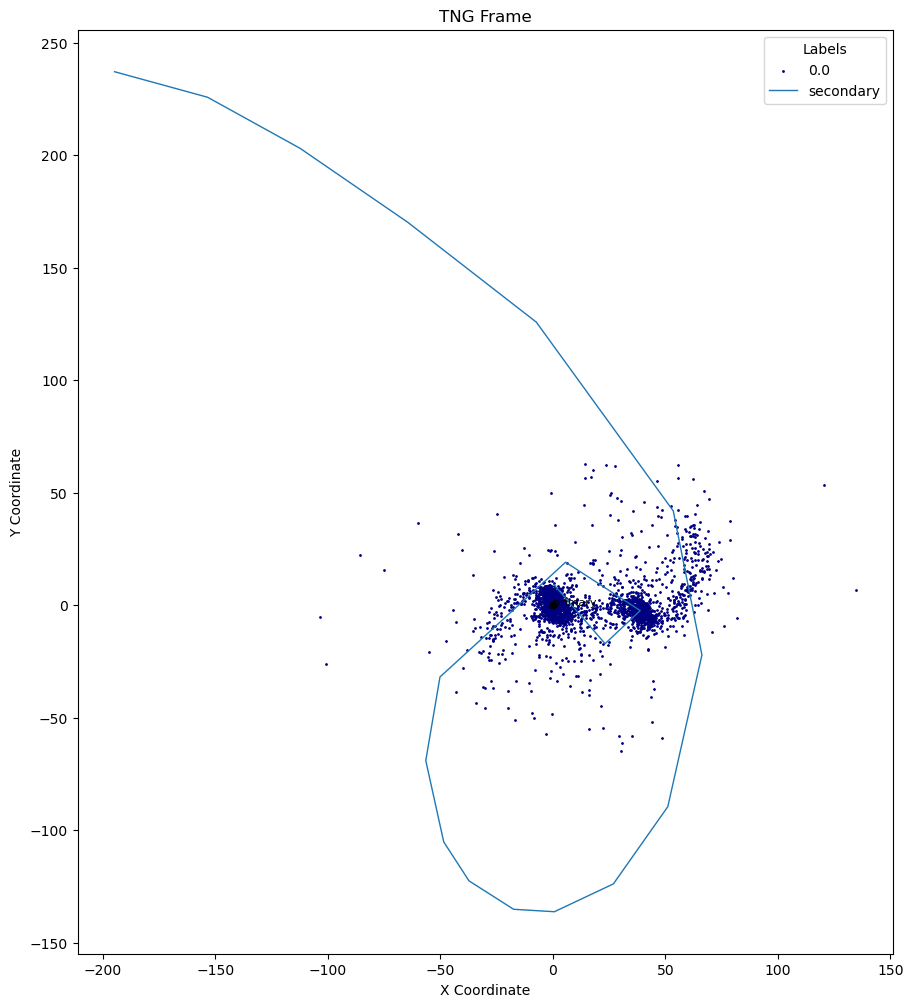

In [13]:
def get_moving_path( t_row, t_df, dev_print = False ):

    # Get the final position and velocity in frame
    p_pos = t_row['p_SubhaloPos_orbital_frame']
    s_pos = t_row['s_SubhaloPos_orbital_frame']
    p_vel = t_row['p_SubhaloVel_orbital_frame']
    s_vel = t_row['s_SubhaloVel_orbital_frame']

    # Get the tranform needed to convert to orbital frame
    pos_transform = t_row['orbital_frame_pos_transform']
    vel_transform = t_row['orbital_frame_vel_transform']

    # Get raw position and velocity data
    p_path_raw_pos = np.stack(t_df['p_SubhaloPos'].values)
    s_path_raw_pos = np.stack(t_df['s_SubhaloPos'].values)
    p_path_raw_vel = np.stack(t_df['p_SubhaloVel'].values)
    s_path_raw_vel = np.stack(t_df['s_SubhaloVel'].values)

    if dev_print:

        print(f"positions type: {type(p_pos)}")
        print(f"Primary Position: {p_pos}")
        print(f"Secondary Position: {s_pos}")
        print(f"Primary Velocity: {p_vel}")
        print(f"Secondary Velocity: {s_vel}")

        print( f"tranform type: {type(pos_transform)}" )
        print( f"Position Transform: \n{pos_transform}" )
        print( f"Velocity Transform: \n{vel_transform}" )

        print( f"Raw Position Type: {type(p_path_raw_pos)}" )
        print( f"Raw Position Data: {p_path_raw_pos.shape}" )
        print( f"Raw Velocity Data: {p_path_raw_vel.shape}" )
    
    p_path_pos = tf.apply_transformation( pos_transform, p_path_raw_pos )
    s_path_pos = tf.apply_transformation( pos_transform, s_path_raw_pos )
    p_path_vel = tf.apply_transformation( vel_transform, p_path_raw_vel )
    s_path_vel = tf.apply_transformation( vel_transform, s_path_raw_vel )

    p_path = np.hstack( [p_path_pos, p_path_vel])
    s_path = np.hstack( [s_path_pos, s_path_vel])

    if dev_print:
        print( f"Transformed Primary Data: {p_path.shape}" )
        print( f"Transformed Secondary Data: {s_path.shape}")
    
    return p_path, s_path

def convert_to_fixed_frame(primary, secondary):
    """
    Convert the orbital paths and velocities to a frame where the primary galaxy is fixed at the origin.

    Args:
    - primary (np.ndarray): Nx6 array of primary galaxy positions and velocities [ x y z vy vy vz ].
    - secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities [ x y z vy vy vz ].

    Returns:
    - fixed_secondary (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary.shape == secondary.shape

    # Convert to fixed frame
    fixed_secondary = secondary - primary

    return fixed_secondary


def convert_to_moving_frame(primary_moving, secondary_fixed):
    """
    Convert the paths and velocities from a fixed primary frame back to the original moving frame.

    Args:
    - primary_moving (np.ndarray): Nx6 array of primary galaxy positions and velocities [x, y, z, vx, vy, vz].
    - secondary_fixed (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the fixed frame.

    Returns:
    - secondary_moving (np.ndarray): Nx6 array of secondary galaxy positions and velocities in the moving frame.
    """
    # Ensure the input arrays have the correct shape
    assert primary_moving.shape == secondary_fixed.shape, "Primary and fixed secondary arrays must have the same shape"
    assert primary_moving.shape[1] == 6, "Each row should contain 6 elements: [x, y, z, vx, vy, vz]"

    # Convert to moving frame
    secondary_moving = secondary_fixed + primary_moving

    return secondary_moving

if buildEnv:

    path = {}

    p_path, s_path = get_moving_path( t_row, t_df, dev_print = True )

    path['p_moving'] = p_path
    path['s_moving'] = s_path

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']

    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    print( pts_tu[:,0:2].shape ) 
    print( pts_tu[:,-2].shape)

    tf.xy_plot( 
        xy_pts = pts_tu[:,0:2],
        plot_lines = path['s_fixed'][7:] , plot_labels=['secondary'], 
        sig_pts=np.array([[0,0,0]]), sig_labels=np.array(['primary']),
        title="TNG Frame", figsize=(12,12), std_dev = 5 )


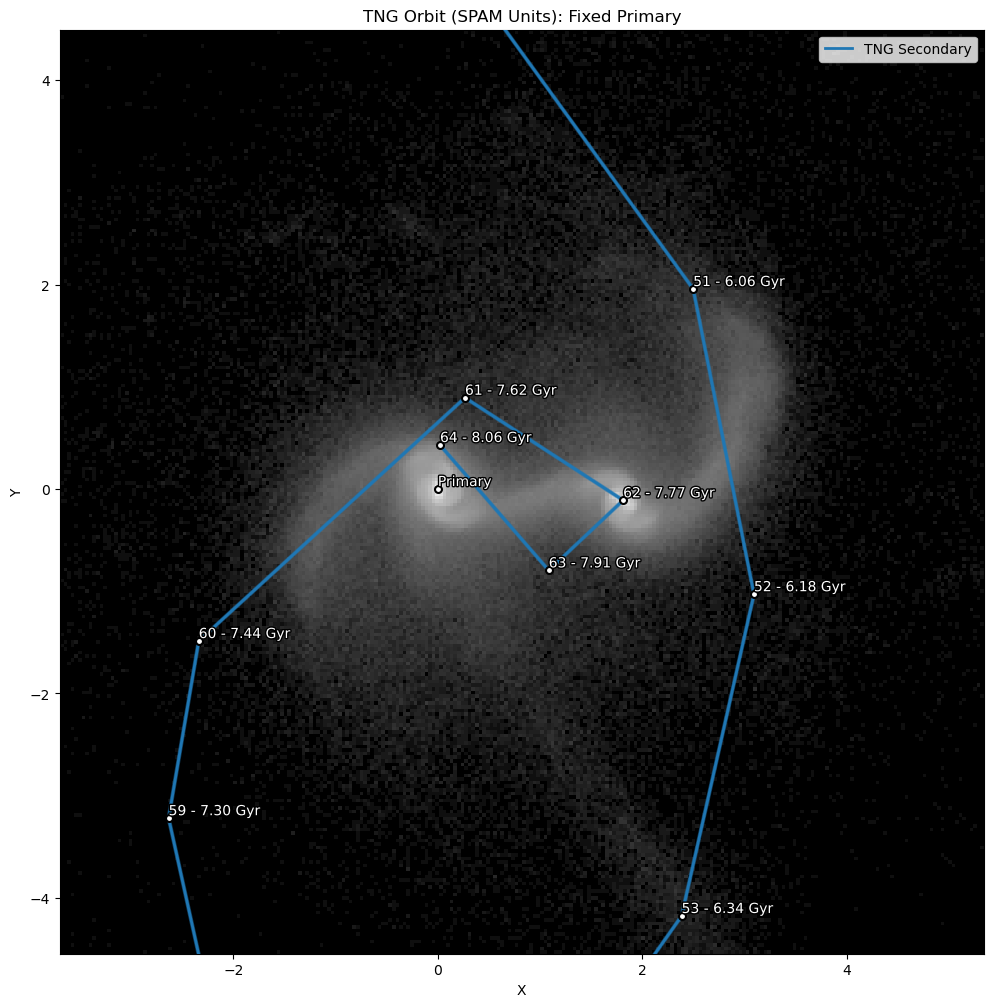

In [14]:
import matplotlib.patheffects as path_effects

def xy_histogram( hist_data,
                plot_data = None, plot_labels = None,
                annotate_data = None,
                limits = None,
                ext_ax=None,  title="2D Histogram", \
                std_dev=3, bins=256, cmap='gray', \
                log_scale=True, dim_inner = -1, \
                show_labels=False, plotting=True, figsize=None):
    """
    Plots a 2D histogram on a given axis with x and y limits set to n standard deviations.

    Args:
    hist_data (np.ndarray): An N x 2 array of xy coordinates.
    plot_data (list or np.ndarray): Optional. List of N x 2 arrays or a single N x 2 array of xy coordinates to overlay on the histogram.
    plot_labels (list or str): Labels for each plot_data item.
    annotate_data (list of tuples): List of (location, text) tuples. Each location is an xy coordinate, and text is a string to annotate.
    limits (tuple): Axis limits for x and y.
    ax (matplotlib.axes.Axes or None): The axis to plot on. If None, a new figure and axis will be created.
    title (str): Title of the subplot.
    std_dev (float): Number of standard deviations to set axis limits.
    bins (int): Number of bins along each axis in the histogram.
    cmap (str): Colormap for the histogram.
    log_scale (bool): Whether to apply logarithmic scaling to the histogram.
    dim_inner (int): Threshold for capping high histogram bin counts.
    show_labels (bool): Whether to show axis labels.
    plotting (bool): If true, shows the plot.
    """

    if hist_data is None:
        raise ValueError("hist_data cannot be None")
    

    # Ensure plot_data and plot_labels are lists
    if plot_data is not None and not isinstance(plot_data, list):
        plot_data = [plot_data]
    if plot_labels is not None and not isinstance(plot_labels, list):
        plot_labels = [plot_labels]


    # If ax is None, create a new figure and axis
    ax = ext_ax or plt.subplots(figsize=figsize)[1]

    # Calculate the mean and standard deviation
    mean_xy = np.mean(hist_data[:, 0:2], axis=0)
    std_xy  = np.std( hist_data[:, 0:2], axis=0)

    # Determine the maximum range to use for both axes
    max_range = np.max(std_xy) * std_dev

    # Set axis limits to be the same for both x and y
    if limits is None:
        xlim = (mean_xy[0] - max_range, mean_xy[0] + max_range)
        ylim = (mean_xy[1] - max_range, mean_xy[1] + max_range)
    else:
        xlim = limits[0]
        ylim = limits[1]

    # Create the histogram
    h, xedges, yedges, image = ax.hist2d(hist_data[:, 0], hist_data[:, 1], bins=bins, range=[xlim, ylim], cmap=cmap)
    
    # 
    if dim_inner != -1:
        
        # Calculate the mean and standard deviation of the histogram bin counts
        mean_bin_count = np.mean(h)
        std_bin_count = np.std(h)

        # Set a threshold to cap the brightest regions
        threshold = mean_bin_count + dim_inner * std_bin_count  # You can adjust this multiplier

        # Apply the threshold to cap the values in the histogram
        h[h > threshold] = threshold  # Cap all bin counts above the threshold

    
    # Apply log1p to enhance visibility of low count regions
    if log_scale:
        h = np.log1p(h)  

    # Clear the axis and plot with modified histogram data
    ax.clear()
    image2 = ax.imshow(h.T, interpolation='nearest', origin='lower', aspect='auto',
                      extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                      cmap=cmap)
    
    # Plot each set of plot_data with a unique color and label
    if plot_data is not None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(plot_data)))  # Choose colors from tab10 colormap
        for i, data in enumerate(plot_data):
            label = plot_labels[i] if plot_labels and i < len(plot_labels) else f"Data {i+1}"
            ax.plot(data[:, 0], data[:, 1], color=colors[i], linewidth=2, zorder=5, label=label)
            ax.plot(data[:, 0], data[:, 1], color=colors[i], linewidth=3, zorder=4, alpha=0.5)

        # Show legend
        ax.legend()
    
    # Annotate data points with large white points and text with a black outline
    if annotate_data is not None:
        for location, text in annotate_data:
            # Check if the annotation is within the plot bounds
            if xlim[0] <= location[0] <= xlim[1] and ylim[0] <= location[1] <= ylim[1]:
                ax.scatter(*location, color='white', s=25, edgecolor='black', linewidth=1.5, zorder=6)  # Large white point with black outline
                text_obj = ax.text(location[0], location[1], text, fontsize=10, color='white',
                                ha='left', va='bottom', zorder=7)
                # Apply a black outline to text
                text_obj.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])


    # Set titles and labels
    ax.set_title(title)
    
    if show_labels:
        # Add axis labels and ticks (they are no longer removed)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    else:   
        # Remove the axis labels and ticks
        ax.set_xticks([])
        ax.set_yticks([])
    
    ax.legend()

    # Set axis limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')

    # If ax was None, display the plot
    if ax is None:
        plt.show()
    
    return

if buildEnv:

    # convert tng pts to spam units
    pts_su = np.copy( pts_raw )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    path['times_su'] = convert_time_tng_to_spam( path['times'] )

    # Create list of tuples from secondary fixed path and snap data
    base_annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]

    # Add origin as primary galaxy
    base_annotate_data.append( ([0,0], 'Primary') )

    xy_histogram( \
        pts_su, \
        path['s_fixed_su'], 'TNG Secondary', \
        show_labels = True, std_dev = 4,
        annotate_data= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary',
        figsize=(12,12)
    )

## Creating Splines

So, I want to study the points/orbit between snapshots, specifically the moments of closest approach or fly-by events.  So let's do that.

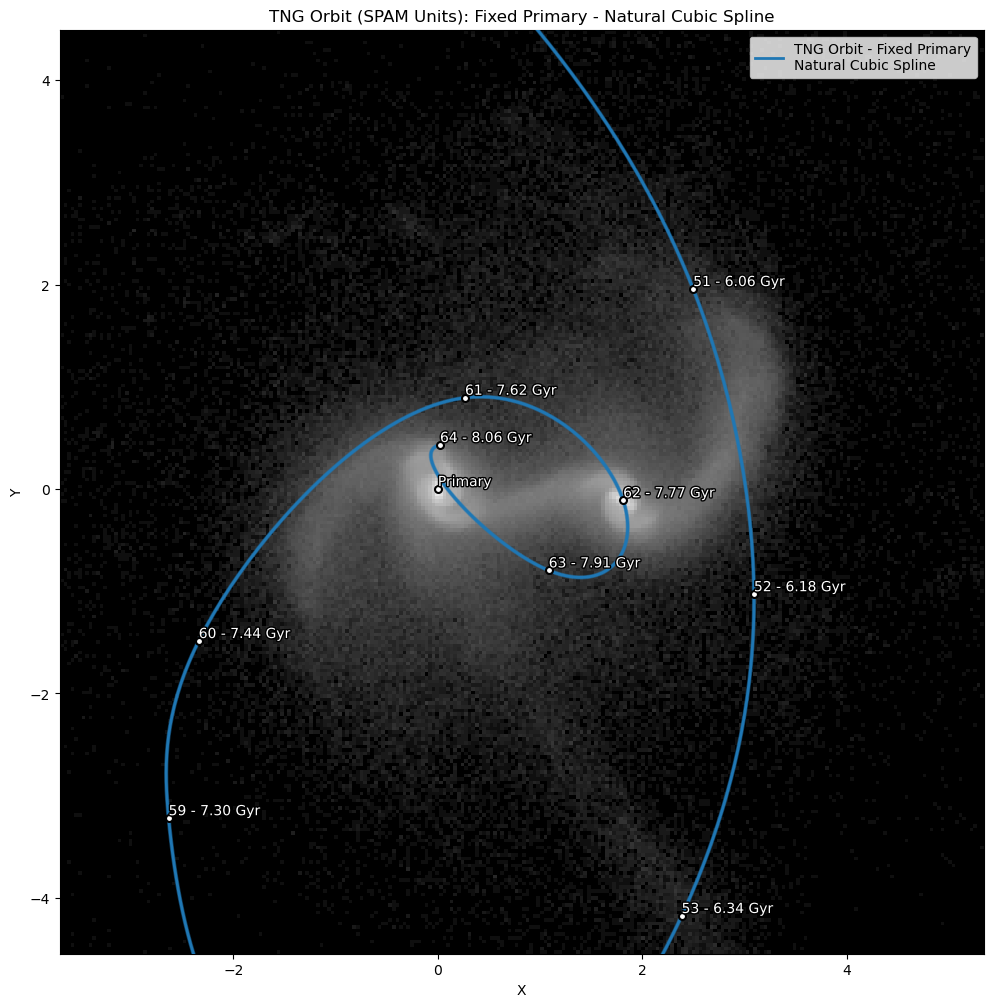

In [15]:

def interpolate_path_natural_cubic(times, path):

    # Extract positions and velocities
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create cubic splines with clamped boundary conditions using endpoint velocities
    spline_x = CubicSpline(times, x, bc_type=((1, dx[0]), (1, dx[-1])))
    spline_y = CubicSpline(times, y, bc_type=((1, dy[0]), (1, dy[-1])))
    spline_z = CubicSpline(times, z, bc_type=((1, dz[0]), (1, dz[-1])))

    # Add the splines and their derivative functions to a list
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines

if buildEnv:


    # Create cubic splines
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])

    # Generate a test set of times
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )

    # Evaluate the splines at the test times
    path['s_fixed_su_cubic_nat_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_nat_func']] for t in path['s_times_test'] ])

    # Send to histogram 
    xy_histogram( \
        pts_su, \
        path['s_fixed_su_cubic_nat_test'], 'TNG Orbit - Fixed Primary\nNatural Cubic Spline', \
        show_labels = True, std_dev = 4,
        annotate_data= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Natural Cubic Spline',
        figsize=(12,12)
    )


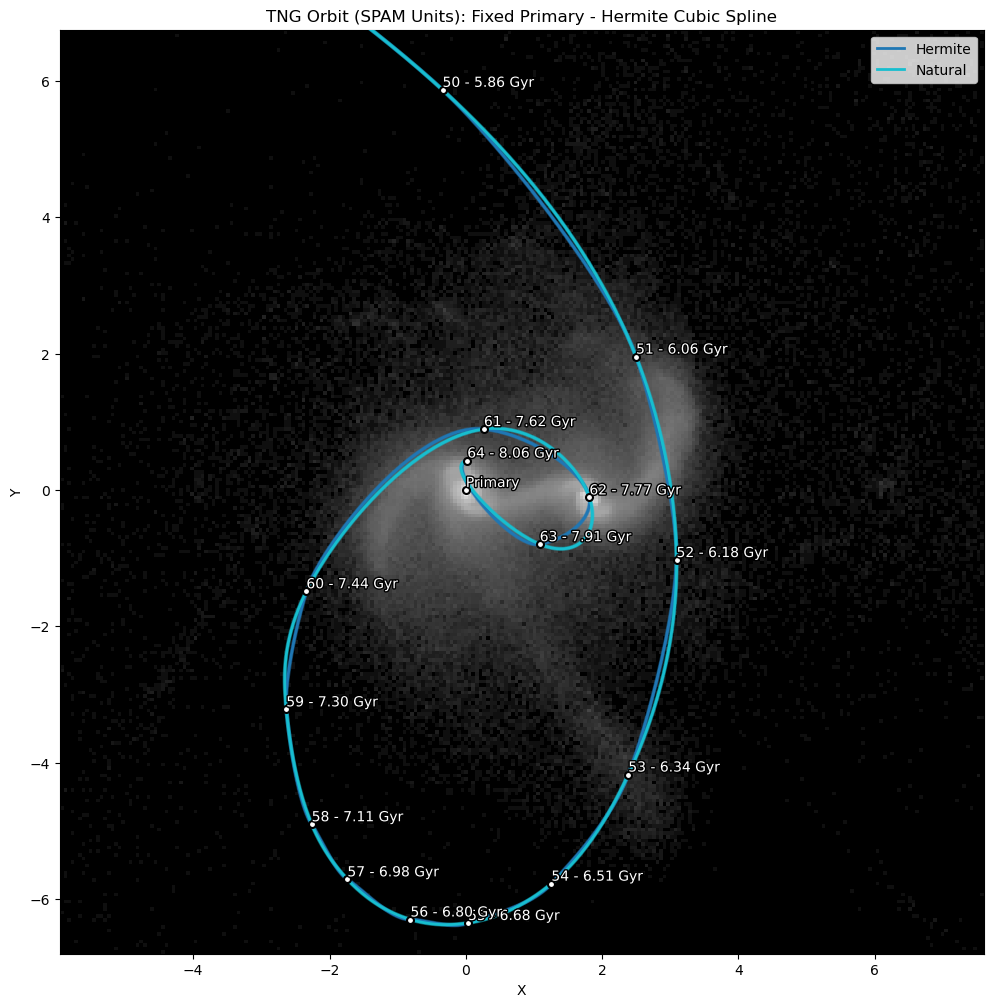

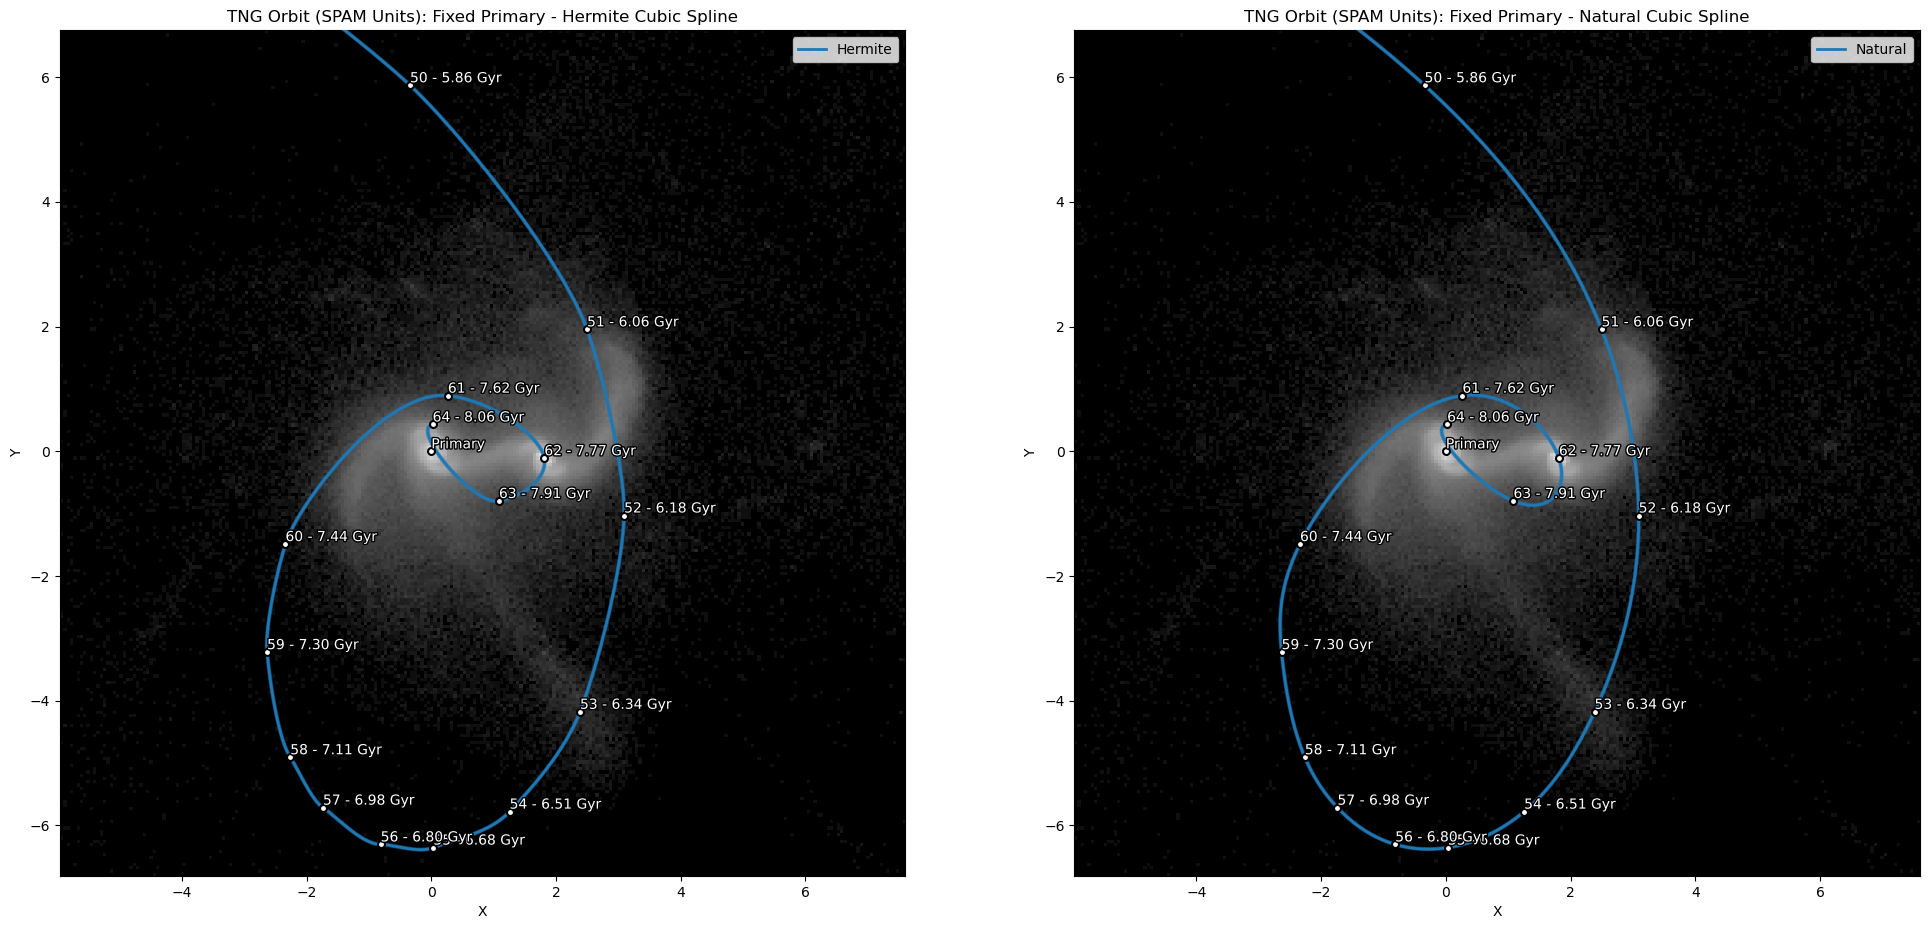

In [ ]:
from scipy.interpolate import CubicHermiteSpline

def interpolate_path_with_velocities(times, path):

    # Separate positions and velocities into x, y, z components
    x, y, z = path[:, 0], path[:, 1], path[:, 2]
    dx, dy, dz = path[:, 3], path[:, 4], path[:, 5]

    # Create Hermite splines for each dimension
    spline_x = CubicHermiteSpline(times, x, dx)
    spline_y = CubicHermiteSpline(times, y, dy)
    spline_z = CubicHermiteSpline(times, z, dz)

    # Create list of splines and their derivative functions
    splines = [spline_x, spline_y, spline_z, spline_x.derivative(), spline_y.derivative(), spline_z.derivative()]

    return splines

if buildEnv:

    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    plots = [path['s_fixed_su_cubic_herm_test'],path['s_fixed_su_cubic_nat_test']]
    plot_labels = ['Hermite', 'Natural']

    
    base_plot_list = [path['s_fixed_su_cubic_herm_test']]
    base_plot_labels = ['Hermite']
    sd = 6

    # # Send to histogram 
    xy_histogram( \
        pts_su, \
        plots, plot_labels, \
        show_labels = True, std_dev = sd,
        annotate_data= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Hermite Cubic Spline',
        figsize=(12,12)
    )
    

    # Create two subplots left and right
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))
    
    # Feed one plot to each subplot with the same pts data
    xy_histogram( \
        pts_su, \
        plots[0], plot_labels[0], \
        show_labels = True, std_dev = sd,
        annotate_data= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Hermite Cubic Spline',
        ext_ax = axs[0]
    )

    xy_histogram( \
        pts_su, \
        plots[1], plot_labels[1], \
        show_labels = True, std_dev = sd,
        annotate_data= base_annotate_data,
        title = 'TNG Orbit (SPAM Units): Fixed Primary - Natural Cubic Spline',
        ext_ax = axs[1]
    )


## Analysing Splines

According to ChatGPT, Hermites require positions and velocities to be perfect matches, but it does so via abrupt changes in acceleration.  This makes the curve look unnatural to me, like it's focusing on connecting dots quickly. Natural cubic's on the other hand, do their best to minimize acceleration and thus smooths velocity and acceleration.  Which makes it look intuitively smoother but it does make the velocity data is less accurate.  I also played around with estimating accelerations and creating a quintic spline...  This was jerkier and worse than the hermite.  

However, comparing the Hermite and natural spline there does not appear to be any obvious gaps or changes in position (Except at the very end when they merge, which is not a focus).  And given the spline is an interpolation in the first place, there will always be a bit of error between points no matter which inpertoloation I use. 

So let's just use the hermite for (hopefully) the more accurate velocities.  (NO MORE SPLINES MATTHEW)

In [17]:
if buildEnv:
    
    base_plot_list = [path['s_fixed_su_cubic_herm_test']]
    base_plot_labels = ['Hermite']

In [19]:
def spam_orbit_wrapper_squared( spam_ar, current_time = 0.0, dev_print=False ):
    """
    Wrapper function to run the SPAM simulator with the given SPAM parameters.

    Args:
    - spam_ar (np.ndarray): Array of SPAM parameters.
    - dynamic_friction_lnl (float): The strength of dynamical friction in the SPAM simulation.
    - current_time (float): The current time in the SPAM simulation.
    - dev_print (bool): Whether to print debug information.
+
    Returns:
    - spam_orbit (np.ndarray): Array of SPAM orbit data.
    """

    # Run the SPAM simulator with the given parameters
    spam_orbit = sim.orbit_run_wrapper(spam_ar)

    # Extract the times and correct
    # if dev_print:
    #     print("Before Times: ", spam_orbit[:, -1])

    spam_orbit[:,-1] += current_time - spam_orbit[-1,-1]

    return spam_orbit

def add_annotate_times( data_in, new_path, times_su, dev_print=False ):

    data_out = data_in.copy()

    # If it's inside, use the closest time to the spam time.
    for i,t in enumerate(times_su):

        # Always add first row of new_path
        data_out.append( ( new_path[0, 0:2], f"{convert_time_spam_to_tng(new_path[0,-1]):.2f} Gyr") )


        # if time is outside range of spam sim, don't use it
        if t > new_path[0,-1] and t and new_path[-1,-1]:
            idx = np.argmin(np.abs(new_path[:,-1] - t))
            data_out.append( ( new_path[idx, 0:2], f"{convert_time_spam_to_tng(t):.2f} Gyr") )
        
    return data_out

# Back to TNG
if buildEnv and False:

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    t_df['times_su'] = convert_time_tng_to_spam( t_df['time_gyr'].values )
    t_row['times_su'] = convert_time_tng_to_spam( t_row['time_gyr'] )

    # For my experimental data
    spam_annotate_data = base_annotate_data.copy()    
    spam_plot_list = base_plot_list.copy()
    spam_plot_labels = base_plot_labels.copy()
    
    # Prep for SPAM Simulation
    lnl = 0.025
    sim.set_simulation_variables( lnl=lnl)
    path['spam_exp_1'] = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path['spam_exp_1'] )
    spam_plot_labels.append(f'SPAM Exp 1: lnl={lnl}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path['spam_exp_1'], t_df['times_su'] )

    lnl = 0.1
    sim.set_simulation_variables( lnl=lnl)
    path['spam_exp_2'] = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path['spam_exp_2'] )
    spam_plot_labels.append(f'SPAM Default Units: lnl={lnl}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path['spam_exp_2'], t_df['times_su'] )

    xy_histogram( \
        pts_su, \
        spam_plot_list, spam_plot_labels, \
        show_labels = True, std_dev = 4,
        annotate_data= spam_annotate_data,
        title = 'SPAM Simulation: Fixed Primary',
        figsize=(12,12)
    )

    # print( spam_orbit_raw )


In [20]:

# Back to TNG
if buildEnv and False:

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    # t_df['times_su'] = convert_time_tng_to_spam( t_df['time_gyr'].values )
    # t_row['times_su'] = convert_time_tng_to_spam( t_row['time_gyr'] )

    # For my experimental data
    spam_annotate_data = base_annotate_data.copy()    
    spam_plot_list = base_plot_list.copy()
    spam_plot_labels = base_plot_labels.copy()
    
    # Prep for SPAM Simulation
    lnl = 0.01
    rscale = 15.0
    sim.set_simulation_variables( lnl=lnl, r_scale=rscale)
    path_exp_1 = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path_exp_1 )
    spam_plot_labels.append(f'Exp: lnl={lnl} rscale={rscale}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path_exp_1, t_df['times_su'] )

    lnl = 0.007
    rscale = 20
    sim.set_simulation_variables( lnl=lnl, r_scale=rscale)
    path_exp_2 = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path_exp_2 )
    spam_plot_labels.append(f'Exp: lnl={lnl} rscale={rscale}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path_exp_2, t_df['times_su'] )
    
    xy_histogram( \
        pts_su, \
        spam_plot_list, spam_plot_labels, \
        show_labels = True, std_dev = 4,
        annotate_data= spam_annotate_data,
        title = 'SPAM Simulation: Fixed Primary',
        figsize=(12,12)
    )

    # print( spam_orbit_raw )


In [21]:

# Back to TNG
if buildEnv and False:

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )
    test_spam_ar = spam_ar.copy()

    # t_df['times_su'] = convert_time_tng_to_spam( t_df['time_gyr'].values )
    # t_row['times_su'] = convert_time_tng_to_spam( t_row['time_gyr'] )

    # For my experimental data
    spam_annotate_data = base_annotate_data.copy()    
    spam_plot_list = base_plot_list.copy()
    spam_plot_labels = base_plot_labels.copy()
    

    lnl = 0.007
    rscale = 20
    mhalo=5.8
    sim.set_simulation_variables( lnl=lnl, r_scale=rscale, mhalo=mhalo)
    path_exp_2 = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path_exp_2 )
    spam_plot_labels.append(f'Exp: mhalo = {mhalo}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path_exp_2, t_df['times_su'] )

    # Slow does initial orbit and increase dynamical friction
    lnl = 0.007
    rscale = 20
    mhalo = 10.0
    sim.set_simulation_variables( lnl=lnl, r_scale=rscale, mhalo=mhalo)
    path_exp_2 = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path_exp_2 )
    spam_plot_labels.append(f'Exp: mhalo = {mhalo}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path_exp_2, t_df['times_su'] )

    xy_histogram( \
        pts_su, \
        spam_plot_list, spam_plot_labels, \
        show_labels = True, std_dev = 4,
        annotate_data= spam_annotate_data,
        title = 'SPAM Simulation: Fixed Primary',
        figsize=(12,12)
    )

    # print( spam_orbit_raw )


In [59]:

if buildEnv and False:
    
    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    # For my experimental data
    spam_annotate_data = base_annotate_data.copy()    
    spam_plot_list = base_plot_list.copy()
    spam_plot_labels = base_plot_labels.copy()
    
    lnl = 0.007
    rscale = 20
    mhalo=5.8
    sim.set_simulation_variables( lnl=lnl, r_scale=rscale, mhalo=mhalo)
    path_exp_1 = spam_orbit_wrapper_squared( test_spam_ar, current_time=t_row['times_su'], dev_print=True )
    spam_plot_list.append( path_exp_1 )
    spam_plot_labels.append(f'Exp: mhalo = {mhalo}')
    spam_annotate_data = add_annotate_times( spam_annotate_data, path_exp_1, t_df['times_su'] )

    # Create new tng_path from spline func using spam times
    tng_exp_path = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path_exp_1[:,-1] ])
    spam_plot_list.append( tng_exp_path )
    spam_plot_labels.append(f'TNG Spline of SPAM times')
    
    xy_histogram( \
        pts_su, \
        spam_plot_list, spam_plot_labels, \
        show_labels = True, std_dev = 4,
        annotate_data= spam_annotate_data,
        title = 'SPAM Simulation: Fixed Primary',
        figsize=(12,12)
    )

    # print( spam_orbit_raw )    

Running SPAM Simulation with: {'label': 'SPAM Default'}
SPAM Orbit Shape: (879, 7)
Running SPAM Simulation with: {'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8, 'label': 'Discovered by Hand'}
SPAM Orbit Shape: (3463, 7)


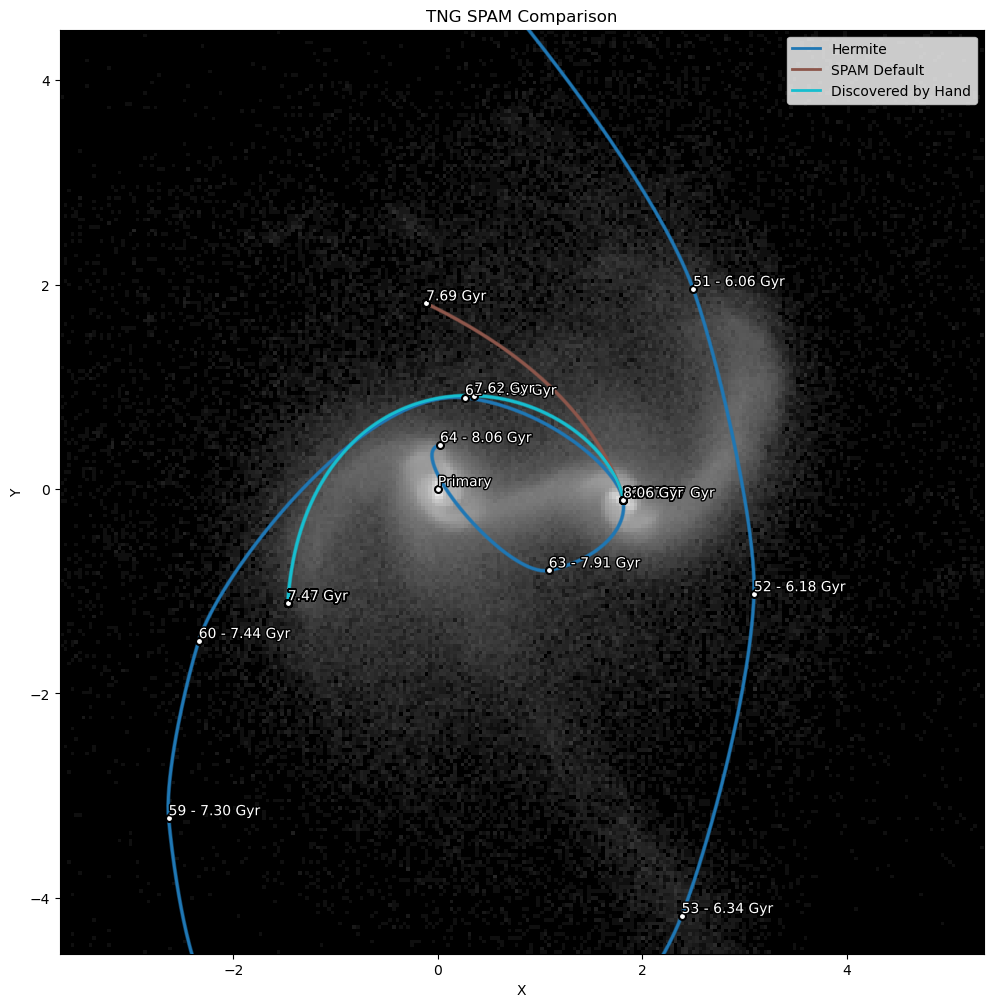

In [72]:
def plot_tng_spam_orbits( t_row, t_df, pts_raw, input_list, dev_print = False, title = 'TNG SPAM Comparison' ):

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    # Extract path
    p_path, s_path = get_moving_path( t_row, t_df )

    # Save in convenient format
    path = {}
    path['p_moving'] = p_path
    path['s_moving'] = s_path
    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']
    
    # convert tng pts to spam units
    pts_su = np.copy( pts_raw )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['times_su'] = convert_time_tng_to_spam( path['times'] )
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    
    # Create Splines for plotting
    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    # Add plots and labels
    plot_list = [path['s_fixed_su_cubic_herm_test']]
    plot_labels = ['Hermite', ]

    # Create list of tuples from secondary fixed path and snap data
    annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]
    annotate_data.append( ([0,0], 'Primary') ) # primary galaxy center

    # Create SPAM orbits
    for x_set in input_list:

        if dev_print:
            print(f"Running SPAM Simulation with: {x_set}")

        # Remove label from x_set
        label = x_set['label']
        del x_set['label']

        # If 'score' is present
        score = None
        if 'score' in x_set:
            score = x_set['score']
            del x_set['score']

        # Use input to prep SPAM simulation
        sim.set_simulation_variables( **x_set )

        # Run SPAM simulation
        spam_orbit = spam_orbit_wrapper_squared( spam_ar, current_time=t_row['times_su'], dev_print=dev_print )

        if dev_print:
            print( f"SPAM Orbit Shape: {spam_orbit.shape}" )
        
        if score is not None:
            score2 = score_run_v1( spam_orbit, path['s_fixed_su_cubic_herm_func'], dev_print=False )

            print(f"{label}: {score} - {score2}")
            
        
        # append to plot lists
        plot_list.append( spam_orbit )
        plot_labels.append( label )
        annotate_data = add_annotate_times( annotate_data, spam_orbit, path['times_su'] )

    # Display final plot
    
    xy_histogram( \
        pts_su, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 4,
        annotate_data= annotate_data,
        title = title,
        figsize=(12,12)
    )

if buildEnv:

    in_var = []
    in_var.append({ 'label':"SPAM Default" })

    in_var.append( {
        'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
        'label': 'Discovered by Hand'
    })

    plot_tng_spam_orbits( t_row, t_df, pts_raw, in_var, True )

In [76]:
# Okay.  Now that we have a working pipeline, let's dev a scoring function that will compare the tng spline with the SPAM spline.

def score_run_v1( spam_path, tng_spline_func, dev_print=False ):
    
    # Create new tng_path from spline func using spam times
    n = len(spam_path)
    tng_exp_path = np.array([ [spline(t) for spline in tng_spline_func] for t in spam_path[:,-1] ])

    # Calculate the average error between the SPAM and TNG paths
    error_ar = np.abs(spam_path[:, 0:3] - tng_exp_path[:, 0:3])**2 / n

    if dev_print:
        # Choice n many points spread throughout the path to print and verify
        n = 10
        idxs = np.linspace( 0, len(spam_path)-1, n, dtype=int )
        for i in idxs:
            print(f"Error: {error_ar[i]} - SPAM: {spam_path[i,0:3]} TNG: {tng_exp_path[i,0:3]}")
    
    return np.sum( error_ar )

if buildEnv:
    score = score_run_v1( path_exp_1, path['s_fixed_su_cubic_herm_func'], dev_print=True )

    print( f"Score: {score}" )

    print( test_spam_ar.tolist() )


Error: [1.30e-04 7.46e-07 6.76e-07] - SPAM: [-1.47 -1.12 -0.25] TNG: [-2.14 -1.07 -0.2 ]
Error: [3.95e-05 1.84e-06 1.26e-07] - SPAM: [-1.39 -0.59 -0.14] TNG: [-1.76 -0.51 -0.12]
Error: [1.62e-06 2.56e-06 1.32e-08] - SPAM: [-1.19 -0.03 -0.02] TNG: [-1.26  0.06 -0.03]
Error: [1.75e-06 5.73e-07 4.25e-07] - SPAM: [-0.77  0.51  0.1 ] TNG: [-0.7   0.55  0.06]
Error: [4.70e-08 1.23e-08 8.35e-07] - SPAM: [-0.13  0.86  0.18] TNG: [-0.12  0.85  0.12]
Error: [4.89e-06 2.14e-07 4.59e-07] - SPAM: [0.56 0.89 0.19] TNG: [0.43 0.87 0.15]
Error: [8.77e-06 8.68e-08 3.12e-07] - SPAM: [1.11 0.71 0.16] TNG: [0.94 0.7  0.13]
Error: [4.36e-06 5.06e-09 3.71e-07] - SPAM: [1.49 0.44 0.11] TNG: [1.37 0.44 0.08]
Error: [5.08e-07 8.80e-10 2.97e-07] - SPAM: [1.72 0.15 0.05] TNG: [1.68 0.15 0.02]
Error: [2.31e-12 1.04e-10 4.49e-12] - SPAM: [ 1.81e+00 -1.11e-01 -1.25e-04] TNG: [ 1.81e+00 -1.10e-01  1.80e-08]
Score: 0.04870923757373346
[1.812701212565104, -0.11041042645772298, 1.798814385741328e-08, 0.0898892722806431

In [75]:
class BlackBoxFunction:

    # Initialize the class
    def __init__(self, pid):

        # Specify the file path to illustrisTNG Target info
        file_path = '/home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/tng-targets/moi-4-targets.pkl'

        # Read the CSV file into a Pandas DataFrame
        tng_targets = pd.read_pickle(file_path, )

        # tng_targets['moi_1'] = tng_targets['moi_1'].astype('int64')
        tng_targets['moi_2'] = tng_targets['moi_2'].astype('int64')
        tng_targets['p_SubhaloIDRaw'] = tng_targets['p_SubhaloIDRaw'].astype('int64')
        tng_targets['s_SubhaloIDRaw'] = tng_targets['s_SubhaloIDRaw'].astype('int64')
        
        # Let's load some orbital data and particles for plotting.
        t_row, t_df = extractTargetData( 62000000190717, tng_targets, dev_print = False )

        # Load the TNG Orbit data
        p_path, s_path = get_moving_path( t_row, t_df, dev_print = False )

        path = {}
        path['p_moving'] = p_path
        path['s_moving'] = s_path
        path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
        path['times'] = np.stack( t_df['time_gyr'].values )
        
        # convert tng pts to spam units
        path['tng_fixed'] = np.copy( path['s_fixed'] )
        path['tng_fixed'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
        path['tng_fixed'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
        path['times_su'] = convert_time_tng_to_spam( path['times'] )

        self.time = convert_time_tng_to_spam( t_row['time_gyr'] )

        # Create spline function from TNG data
        self.spline_func = interpolate_path_with_velocities(path['times_su'], path['tng_fixed'])

        # Get TNG dynamics info for SPAM
        tng_ar = standardize_tng_parameters_v1( t_row )
        self.spam_ar = convert_units_tng_to_spam( tng_ar )
        
    
    def score_run( self, x, ):

        # set parameters
        sim.set_simulation_variables( lnl=x[0], r_scale=x[1], mhalo=x[2])

        # Generate orbit path
        spam_path = spam_orbit_wrapper_squared( self.spam_ar, current_time=self.time )

        # Create new tng_path from spline func using spam times
        tng_exp_path = np.array([ [spline(t) for spline in self.spline_func] for t in spam_path[:,-1] ])

        # Create and apply normalization constant.  The path can be different lengths
        n = len(spam_path)
    
        # Calculate the error between the SPAM and TNG paths
        error_ar = np.abs(spam_path[:, 0:3] - tng_exp_path[:, 0:3])**2 / n
        
        return np.sum( error_ar )

    
if buildEnv:

    black_box = BlackBoxFunction( 62000000190717 )

    in_x = [0.007, 20, 5.8]
    lnl = 0.007
    rscale = 20
    mhalo = 5.8

    score = black_box.score_run(  in_x )
    print( f"Score: {score}" )

Score: 0.04870923757373346


In [77]:
def orbit_gridsearch_1( args, dev_print = False ):

    # Get important parameters
    t_id = args.target_id
    output = args.output
    time_in_sec = int(args.input)

    # prep black box
    black_box = BlackBoxFunction( t_id )

    # Set up grid search variables and bounds
    x_dict = {
        'lnl': {'bounds':[0.001, 1], 'prior': 'log-uniform'},
        'rscale': {'bounds':[1, 60], 'prior': 'uniform'},
        'mhalo': {'bounds':[1, 40], 'prior': 'uniform'}
    }

    # Setup MPI for parallel processing
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    size = comm.Get_size()

    # Setup workers to be on standby
    if rank != 0:
        worker = om.Optimization_Manager( black_box.score_run, x_dict, save_loc = output )
    
    # Setup master to run the optimization
    elif rank == 0:
        manager = om.Optimization_Manager( black_box.score_run, x_dict, save_loc = output )

        results = manager.initial_exploration( time_cutoff_sec= time_in_sec )

        print("FINAL results: ", len(results))

    
    # End the MPI process
 

if buildEnv and False:
    cmdLine = 'python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py'
    cmdLine += ' --function orbit_gridsearch_1'
    cmdLine += ' -id 62000000190717'
    cmdLine += ' --output /home/mbo2d/galStuff/data/orbit_gridsearch/test_62000000190717_1.csv'
    cmdLine += ' --input 10'

    print( cmdLine )
    build_arg = parser.parse_args(cmdLine.split()[2:]) # Skip the first two arguments
    orbit_gridsearch_1( build_arg,  )

    # Save cmdline in a script 
    test_script_loc = '/home/mbo2d/galStuff/cluster/batch_files/test_gridsearch.sh'
    with open(test_script_loc, 'w') as f:
        f.write( cmdLine )

if script_args.function == 'orbit_gridsearch_1':

    orbit_gridsearch_1( script_args, )

In [81]:
if buildEnv and True:

    # okay, create a bunch of scripts to send to my cluster
    run_dir = '/home/mbo2d/galStuff/cluster/batch_files/'
    baseCMD = 'python3 /home/mbo2d/galStuff/galaxyJSPAM/IllustrisTNG/convert_tng_to_spam.py'
    baseCMD += ' --function orbit_gridsearch_1'
    baseCMD += ' -id %s'
    baseCMD += ' --output /home/mbo2d/galStuff/data/orbit_gridsearch/%s_2.csv'
    baseCMD += ' --input %d'
    # Loop through all rows that have moi_4_rating >= 3
    good_targets = tng_targets[tng_targets['moi_4_rating'] >= 4]

    # sort so highest is first
    good_targets = good_targets.sort_values(by='moi_4_rating', ascending=False)

    file_name = 'gridsearch_cmds_2.sh'
    # open file
    f = open(f'{run_dir}/{file_name}', 'w')

    # exe_time 
    n_hr = 6
    exe_time = n_hr * 60*60 # an hour

    for idx, row in good_targets.iterrows():
        t_id = row['p_SubhaloIDRaw']
        cmdLine = baseCMD % (t_id, t_id, exe_time)
        build_arg = parser.parse_args(cmdLine.split()[2:]) # Skip the first two arguments
        
        # Write to file
        f.write( cmdLine + '\n')
    
    f.close()

    # print size of good_targets
    print( f"Good Targets: {len(good_targets)}" )

Good Targets: 63


# Run Gridsearch cmds above via cluster, review results

Results: (13949, 4)
Best Score: 50.37540135134493
    final_value    lnl  rscale  mhalo
0  43938.140101  0.001    1.00    1.0
1  43938.140101  0.001   15.75    1.0
2  43938.140101  0.001   30.50    1.0
3  43938.140101  0.001   45.25    1.0
4  43938.140101  0.001   60.00    1.0

TOP RESULTS
     final_value  lnl     rscale  mhalo
690    50.375401  1.0  34.347826    1.0
689    50.746650  1.0  31.782609    1.0
691    50.864298  1.0  36.913043    1.0
688    51.917318  1.0  29.217391    1.0
Running SPAM Simulation with: {'label': 'SPAM Default'}
SPAM Orbit Shape: (879, 7)
Running SPAM Simulation with: {'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8, 'label': 'Discovered by Hand'}
SPAM Orbit Shape: (3463, 7)
Running SPAM Simulation with: {'lnl': 1.0, 'r_scale': 34.34782608695652, 'mhalo': 1.0, 'label': 'Top Grid Result: 0', 'score': 50.37540135134493}
SPAM Orbit Shape: (784, 7)
Top Grid Result: 0: 50.37540135134493 - 50.37540135134493
Running SPAM Simulation with: {'lnl': 1.0, 'r_scale': 31.78260

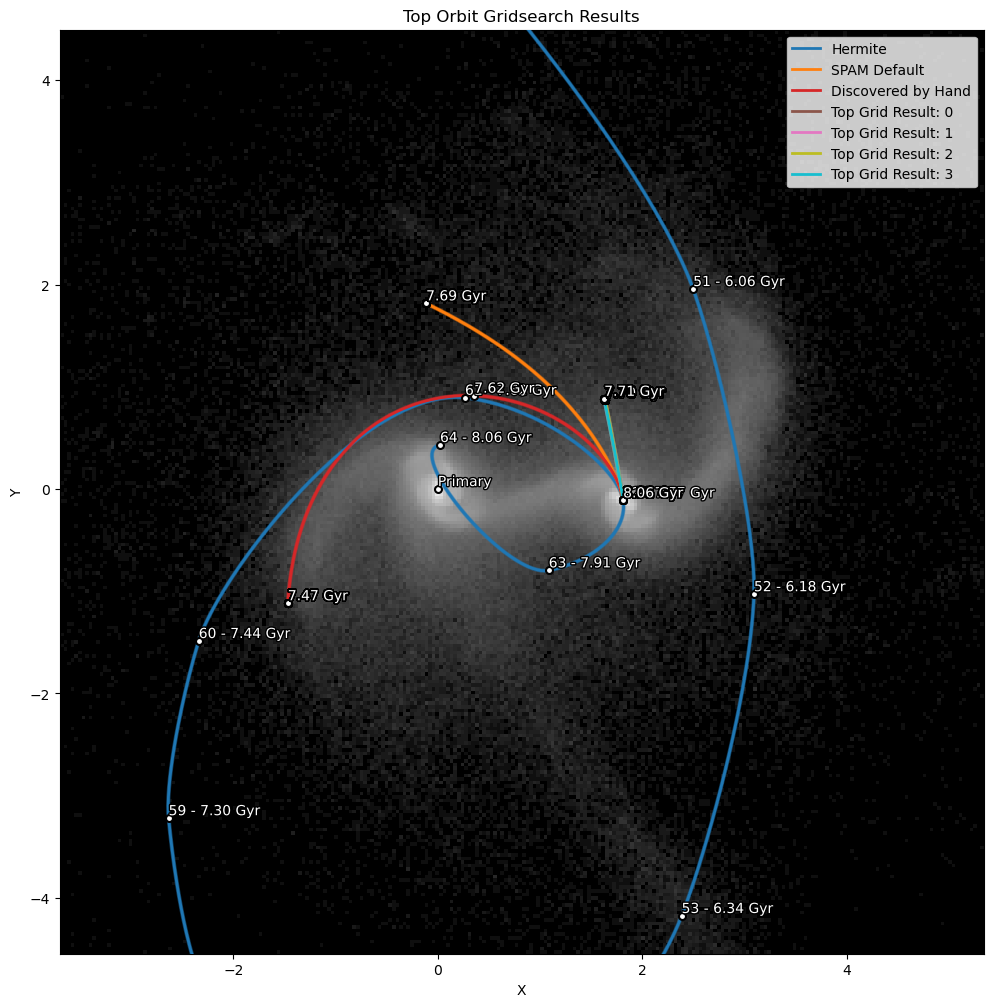

In [74]:
def get_top_results( t_id, n_results = 5, dev_print = False ):
        
        output = '/home/mbo2d/galStuff/data/orbit_gridsearch/%s.csv' % t_id
        grid_search_df = pd.read_csv(output)

        if dev_print:
            print( f"Results: {grid_search_df.shape}" )
            print( f"Best Score:", grid_search_df['final_value'].min() )
            print( grid_search_df.head() )
            

        # Grab the lowest n_results final_value rows
        top_results = grid_search_df.nsmallest(n_results, 'final_value')

        return top_results
    

if buildEnv:
    
        # Get grid_search results
        t_id = 62000000190717

        top_results = get_top_results( t_id, 4, True )

        # Print quantity of unique final values
        print("\nTOP RESULTS")
        print( top_results )

        in_var = []
        in_var.append({ 'label':"SPAM Default" })

        in_var.append( {
                'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
                'label': 'Discovered by Hand', 
        })

        c = 0
        for idx, row in top_results.iterrows():
            in_var.append( {
                'lnl': row['lnl'], 'r_scale': row['rscale'], 'mhalo': row['mhalo'],
                'label': f'Top Grid Result: {c}', 'score': row['final_value']
            })
            c += 1

        plot_tng_spam_orbits( t_row, t_df, pts_raw, in_var, True, title = 'Top Orbit Gridsearch Results' )
                
        # End the MPI process

In [ ]:
def plot_tng_spam_pts( t_row, t_df, pts_raw, x_set, dev_print = False, title = 'TNG SPAM Comparison' ):

    # Get TNG dynamics info 
    tng_ar = standardize_tng_parameters_v1( t_row )
    spam_ar = convert_units_tng_to_spam( tng_ar )

    # Extract path
    p_path, s_path = get_moving_path( t_row, t_df )

    # Save in convenient format
    path = {}
    path['p_moving'] = p_path
    path['s_moving'] = s_path
    path['snaps'] = np.stack( t_df['snap'].values )
    path['times'] = np.stack( t_df['time_gyr'].values )

    path['s_fixed'] = convert_to_fixed_frame( p_path, s_path )
    pts_tu = tf.apply_transformation( t_row['orbital_frame_pos_transform'], pts_raw )
    pts_tu[:,0:3] = pts_tu[:,0:3] - t_row['p_SubhaloPos_orbital_frame']
    
    # convert tng pts to spam units
    pts_su = np.copy( pts_raw )
    pts_su[:,0:3] = convert_distance_tng_to_spam( pts_tu[:,0:3] )
    pts_su[:,3:6] = convert_velocity_tng_to_spam( pts_tu[:,3:6] )

    # Convert the paths to SPAM units
    path['times_su'] = convert_time_tng_to_spam( path['times'] )
    path['p_moving_su'] = np.copy( path['p_moving'] )
    path['p_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['p_moving'][:,0:3] )
    path['p_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['p_moving'][:,3:6] )
    path['s_moving_su'] = np.copy( path['s_moving'] )
    path['s_moving_su'][:,0:3] = convert_distance_tng_to_spam( path['s_moving'][:,0:3] )
    path['s_moving_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_moving'][:,3:6] )
    path['s_fixed_su'] = np.copy( path['s_fixed'] )
    path['s_fixed_su'][:,0:3] = convert_distance_tng_to_spam( path['s_fixed'][:,0:3] )
    path['s_fixed_su'][:,3:6] = convert_velocity_tng_to_spam( path['s_fixed'][:,3:6] )
    
    # Create Splines for plotting
    path['s_fixed_su_cubic_herm_func'] = interpolate_path_with_velocities(path['times_su'], path['s_fixed_su'])
    path['s_fixed_su_cubic_nat_func'] = interpolate_path_natural_cubic(path['times_su'], path['s_fixed_su'])
    path['s_times_test'] = np.linspace( path['times_su'][0], path['times_su'][-1], 1000 )
    path['s_fixed_su_cubic_herm_test'] = np.array([ [spline(t) for spline in path['s_fixed_su_cubic_herm_func']] for t in path['s_times_test'] ])

    # Add plots and labels
    plot_list = [path['s_fixed_su_cubic_herm_test']]
    plot_labels = ['Hermite', ]

    # Create list of tuples from secondary fixed path and snap data
    annotate_data = [(path['s_fixed_su'][i, 0:2], f"{path['snaps'][i]} - {path['times'][i]:.2f} Gyr") for i in range(len(path['snaps']))]
    annotate_data.append( ([0,0], 'Primary') ) # primary galaxy center

    # Create SPAM orbits

    if dev_print:
        print(f"Running SPAM Simulation with: {x_set}")

    # Remove label from x_set
    label = x_set['label']
    del x_set['label']

    # Use input to prep SPAM simulation
    sim.set_simulation_variables( **x_set )

    r_scale = 3
    spam_ar[8:9] = r_scale  * spam_ar[8:9]

    # Run SPAM simulation
    spam_orbit = spam_orbit_wrapper_squared( spam_ar, current_time=t_row['times_su'], dev_print=dev_print )


    if dev_print:
        print( f"SPAM Orbit Shape: {spam_orbit.shape}" )
    
    if score is not None:
        score2 = score_run_v1( spam_orbit, path['s_fixed_su_cubic_herm_func'], dev_print=False )

        print(f"{label}: {score} - {score2}")
    
    # Now run 
    ipts, fpts = sim.basic_run_wrapper( spam_ar, npts1 = 30000, npts2 = 30000, heat1 = 0.1, heat2 = 0.1,)
    
    # append to plot lists
    plot_list.append( spam_orbit )
    plot_labels.append( label )
    annotate_data = add_annotate_times( annotate_data, spam_orbit, path['times_su'] )

    # Create a side by side subplot of size 12x12
    fig, axs = plt.subplots(1, 2, figsize=(24, 12))

    # set overall title
    fig.suptitle(title, fontsize=16)

    # tighter layout
    plt.tight_layout()

    xy_histogram( \
        pts_su, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 3,
        annotate_data= annotate_data,
        title = 'TNG Pts',
        ext_ax = axs[0],
        bins = 200,
    )

    xy_histogram( \
        fpts, \
        plot_list, plot_labels, \
        show_labels = True, std_dev = 3,
        annotate_data= annotate_data,
        title = 'SPAM Pts',
        ext_ax = axs[1],
        bins = 200
    )

if buildEnv:

    x_set = {
        'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8,
        'label': 'Discovered by Hand'
    }

    plot_tng_spam_pts( t_row, t_df, pts_raw, x_set, True )

Running SPAM Simulation with: {'lnl': 0.007, 'r_scale': 20, 'mhalo': 5.8, 'label': 'Discovered by Hand'}


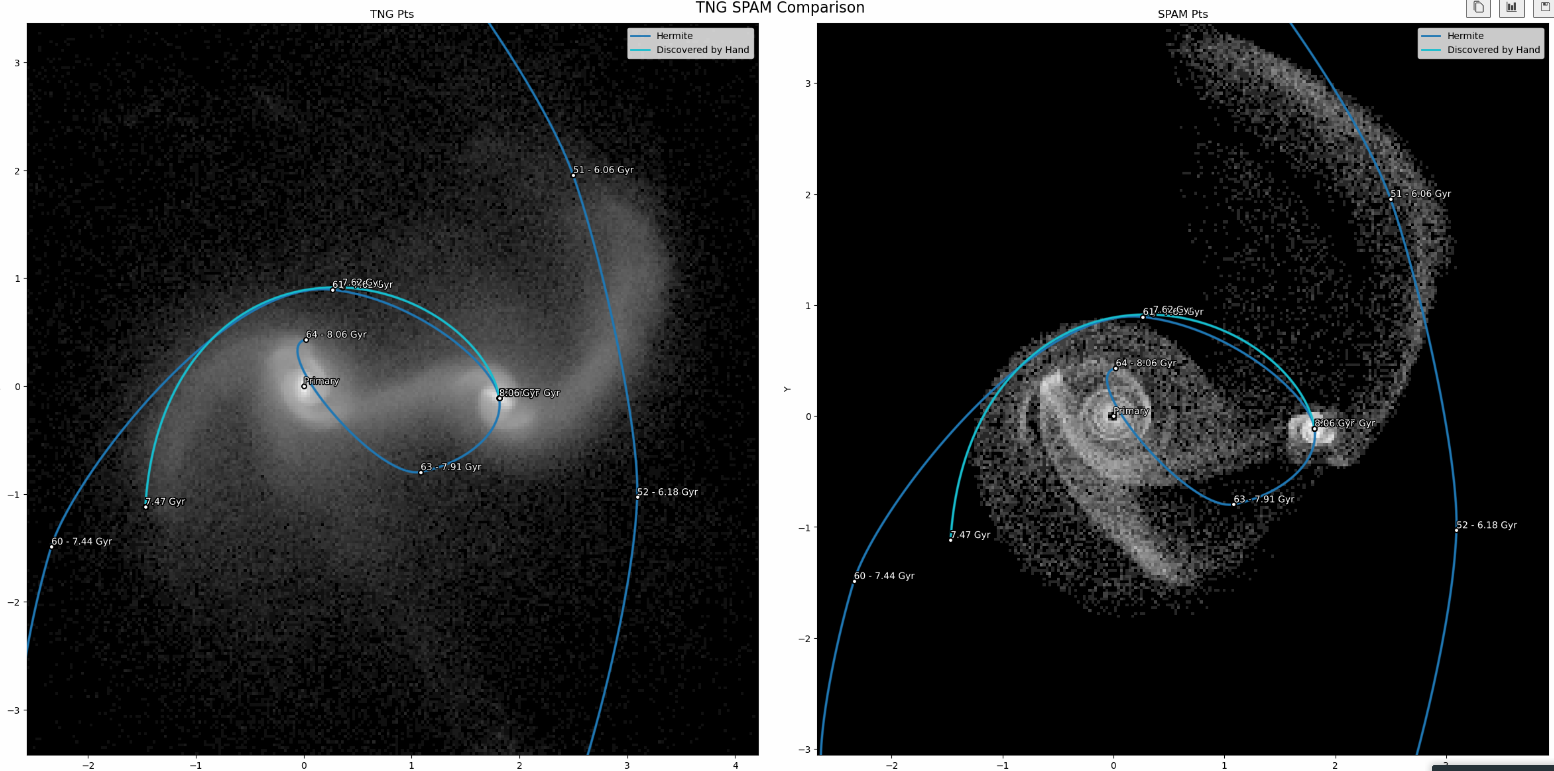